In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
from google.colab import files

uploaded = files.upload()

Saving superstore.csv to superstore.csv


In [8]:
import pandas as pd

df = pd.read_csv("superstore.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 10800
Columns: 21


In [9]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    998

In [10]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [11]:
# Remove rows where Order Date is missing
df_clean = df.dropna(subset=["Order Date"]).copy()

print("Rows before cleaning:", len(df))
print("Rows after removing invalid rows:", len(df_clean))

Rows before cleaning: 10800
Rows after removing invalid rows: 9994


In [12]:
print("Remaining missing values:")
print(df_clean.isnull().sum())

Remaining missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [13]:
# Check for completely duplicated rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
print("Duplicate Row IDs:", df_clean["Row ID"].duplicated().sum())

Duplicate Row IDs: 0


In [15]:
# Convert Order Date and Ship Date from text to datetime
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

print(df_clean[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [16]:
# Create useful date-related columns
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter

print(df_clean[["Order Date", "Year", "Month", "Month Name", "Quarter"]].head())

  Order Date  Year  Month Month Name  Quarter
0 2017-11-08  2017     11   November        4
1 2017-11-08  2017     11   November        4
2 2017-06-12  2017      6       June        2
3 2016-10-11  2016     10    October        4
4 2016-10-11  2016     10    October        4


In [17]:
# Save the cleaned dataset
df_clean.to_csv("superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Cleaned dataset saved successfully!
Rows: 9994
Columns: 25


In [18]:
print("Final dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head())

Final dataset shape: (9994, 25)

Missing values:
Postal Code    11
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
dtype: int64


In [19]:
# Descriptive statistics for numerical columns
df_clean[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [20]:
# Correlation between numerical variables
correlation = df_clean[["Sales", "Quantity", "Discount", "Profit"]].corr()

print(correlation.round(2))

          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


In [21]:
category_analysis = df_clean.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean")
).sort_values("Total_Sales", ascending=False)

category_analysis.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount
Category,,,,
Technology,836154.03,145454.95,6939.0,0.13
Furniture,741999.80,18451.27,8028.0,0.17
Office Supplies,719047.03,122490.80,22906.0,0.16


In [22]:
subcategory_analysis = df_clean.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean")
).sort_values("Total_Profit", ascending=False)

subcategory_analysis.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount
Sub-Category,,,,
Copiers,149528.03,55617.82,234.0,0.16
Phones,330007.05,44515.73,3289.0,0.15
Accessories,167380.32,41936.64,2976.0,0.08
Paper,78479.21,34053.57,5178.0,0.07
Binders,203412.73,30221.76,5974.0,0.37
Chairs,328449.10,26590.17,2356.0,0.17
Storage,223843.61,21278.83,3158.0,0.07
Appliances,107532.16,18138.01,1729.0,0.17
Furnishings,91705.16,13059.14,3563.0,0.14


In [23]:
# Checking outliers using IQR method

columns = ["Sales", "Quantity", "Discount", "Profit"]

for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_limit) |
        (df_clean[col] > upper_limit)
    ]

    print(f"\n{col}")
    print("Lower Limit:", round(lower_limit, 2))
    print("Upper Limit:", round(upper_limit, 2))
    print("Number of Outliers:", len(outliers))


Sales
Lower Limit: -271.71
Upper Limit: 498.93
Number of Outliers: 1167

Quantity
Lower Limit: -2.5
Upper Limit: 9.5
Number of Outliers: 170

Discount
Lower Limit: -0.3
Upper Limit: 0.5
Number of Outliers: 856

Profit
Lower Limit: -39.72
Upper Limit: 70.82
Number of Outliers: 1881


In [24]:
region_analysis = df_clean.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean")
).sort_values("Total_Sales", ascending=False)

region_analysis.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount
Region,,,,
West,725457.82,108418.45,12266.0,0.11
East,678781.24,91522.78,10618.0,0.15
Central,501239.89,39706.36,8780.0,0.24
South,391721.90,46749.43,6209.0,0.15


In [25]:
year_analysis = df_clean.groupby("Year").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
)

year_analysis.round(2)

,Total_Sales,Total_Profit,Total_Quantity
Year,,,
2015,484247.50,49543.97,7581.0
2016,470532.51,61618.60,7979.0
2017,609205.60,81795.17,9837.0
2018,733215.26,93439.27,12476.0


In [26]:
monthly_analysis = df_clean.groupby(["Month", "Month Name"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).sort_index()

monthly_analysis.round(2)

,,Total_Sales,Total_Profit,Total_Quantity
Month,Month Name,,,
1,January,94924.84,9134.45,1475.0
2,February,59751.25,10294.61,1067.0
3,March,205005.49,28594.69,2564.0
4,April,137762.13,11587.44,2447.0
5,May,155028.81,22411.31,2791.0
6,June,152718.68,21285.80,2680.0
7,July,147238.10,13832.66,2705.0
8,August,159044.06,21776.94,2784.0
9,September,307649.95,36857.48,5062.0


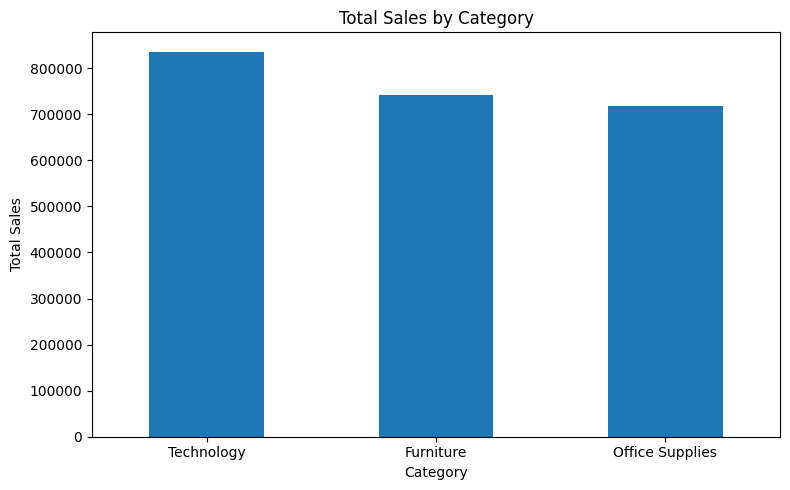

In [34]:
import matplotlib.pyplot as plt

category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("Sales_by_Category.png", dpi=300, bbox_inches="tight")

plt.show()

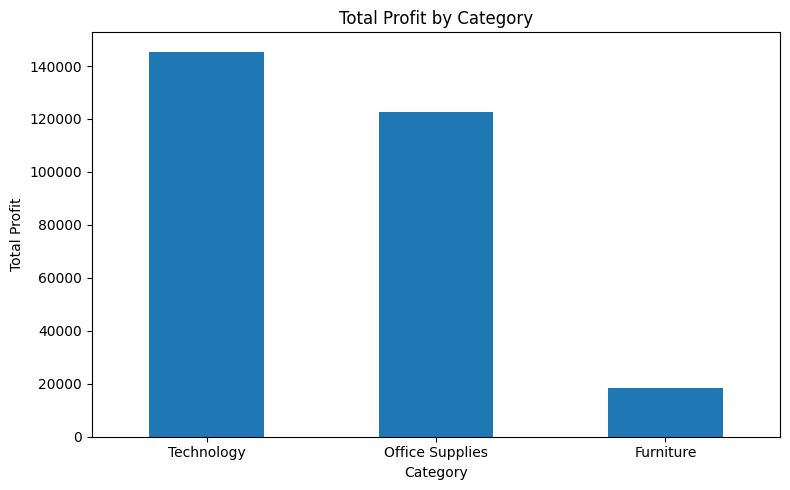

In [35]:
import matplotlib.pyplot as plt

category_profit = df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Profit_by_Category.png", dpi=300, bbox_inches="tight")
plt.show()

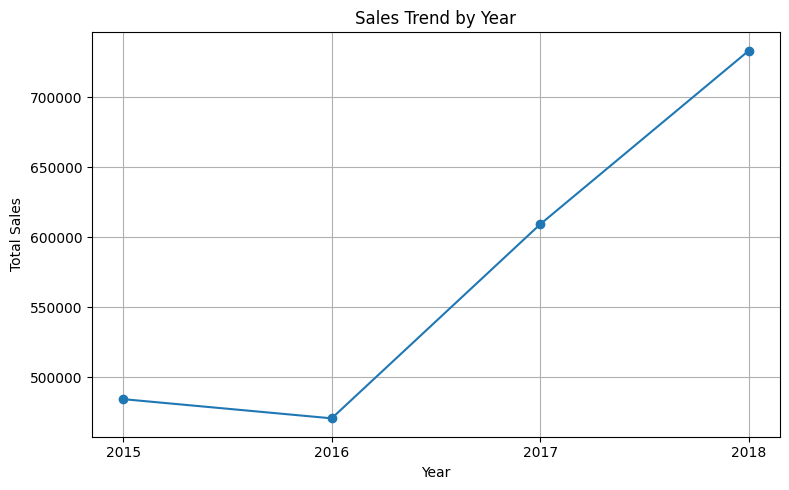

In [36]:
import matplotlib.pyplot as plt

year_sales = df_clean.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8, 5))
year_sales.plot(kind="line", marker="o")

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(year_sales.index)
plt.grid(True)

plt.tight_layout()
plt.savefig("Sales_Trend_by_Year.png", dpi=300, bbox_inches="tight")
plt.show()

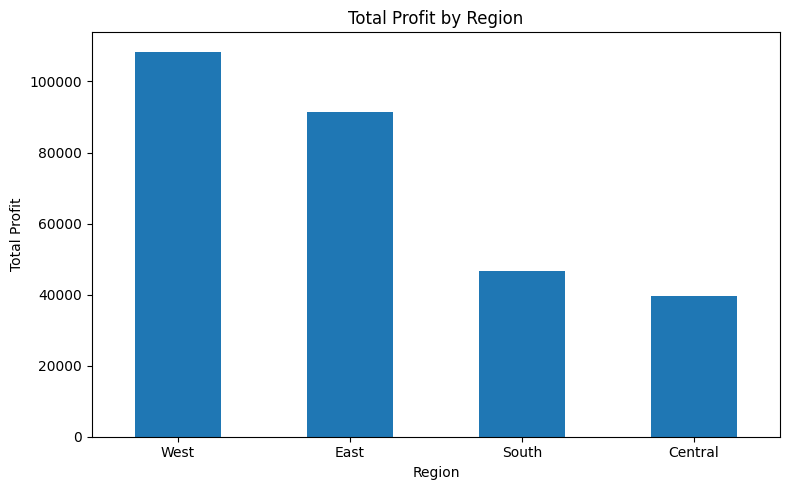

In [37]:
import matplotlib.pyplot as plt

region_profit = df_clean.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Profit_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()

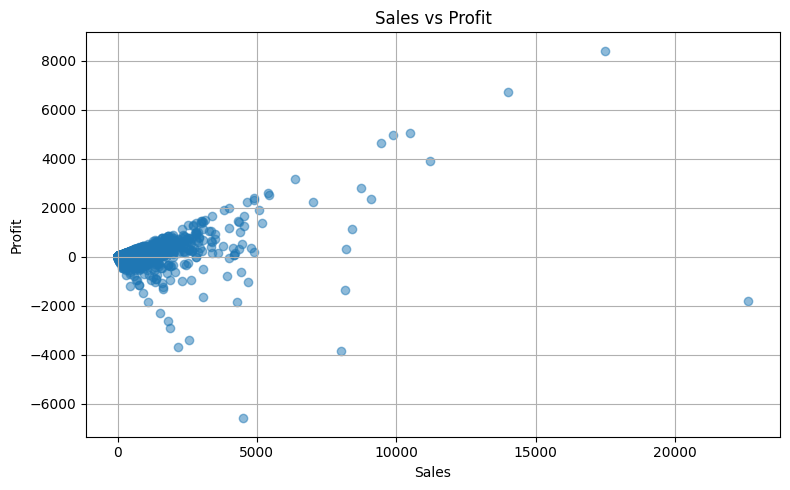

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Sales"],
    df_clean["Profit"],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)

plt.tight_layout()
plt.savefig("Sales_vs_Profit.png", dpi=300, bbox_inches="tight")
plt.show()